In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

In [3]:
TEST_NUM = OPTIONS['dynamic_tests'].get('reference')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'roll', 'limits': [5, 60]}

In [4]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,az,ay,roll,ax,wz,la_pos_mon_d,wx,time,q2,sample_time,yaw,q0,q1,wy,pitch,q3
0,0.07530,-9.786,0.000824,0.1685,0.000022,0.000,0.000121,0.000000,-0.000388,305000000.0,-0.003589,1.0000,0.000412,0.000053,-0.000770,-0.001796
1,0.07581,-9.787,0.000873,0.1686,-0.000382,0.000,0.000495,0.133179,-0.000398,405000000.0,-0.003624,1.0000,0.000437,-0.000202,-0.000793,-0.001813
2,0.07643,-9.784,0.000858,0.1693,0.000108,0.000,-0.000473,0.272078,-0.000408,505000000.0,-0.003620,1.0000,0.000430,-0.000173,-0.000812,-0.001811
3,0.07558,-9.787,0.000870,0.1686,-0.000220,0.000,-0.000015,0.414461,-0.000424,705000000.0,-0.003650,1.0000,0.000436,-0.000259,-0.000843,-0.001827
4,0.07574,-9.785,0.000885,0.1687,-0.000188,0.000,0.000128,0.555454,-0.000433,805000000.0,-0.003666,1.0000,0.000444,-0.000191,-0.000862,-0.001834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,0.08207,-9.786,1.580000,0.1833,-0.000118,-3.404,0.000111,78.196510,0.103700,505000000.0,0.279900,0.6974,0.702900,0.000092,0.013150,0.093520
548,0.08176,-9.786,1.581000,0.1831,-0.000157,-3.400,0.000300,78.338021,0.103700,605000000.0,0.279900,0.6974,0.702900,-0.000174,0.013180,0.093510
549,0.08186,-9.786,1.581000,0.1831,-0.000443,-3.397,0.000360,78.476912,0.103700,705000000.0,0.279900,0.6974,0.702900,0.000025,0.013230,0.093490
550,0.08167,-9.786,1.581000,0.1836,-0.000332,-3.389,0.000221,78.612764,0.103700,905000000.0,0.279900,0.6974,0.703000,-0.000168,0.013290,0.093470


- Convertendo pra radianos

In [6]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,az,ay,roll,ax,wz,la_pos_mon_d,wx,time,q2,sample_time,yaw,q0,q1,wy,pitch,q3
0,0.07530,-9.786,0.047200,0.1685,0.001281,0.000,0.006956,0.000000,-0.000388,305000000.0,-0.205635,1.0000,0.000412,0.003020,-0.044141,-0.001796
1,0.07581,-9.787,0.050042,0.1686,-0.021870,0.000,0.028373,0.133179,-0.000398,405000000.0,-0.207640,1.0000,0.000437,-0.011562,-0.045453,-0.001813
2,0.07643,-9.784,0.049166,0.1693,0.006205,0.000,-0.027112,0.272078,-0.000408,505000000.0,-0.207411,1.0000,0.000430,-0.009912,-0.046541,-0.001811
3,0.07558,-9.787,0.049824,0.1686,-0.012628,0.000,-0.000875,0.414461,-0.000424,705000000.0,-0.209130,1.0000,0.000436,-0.014863,-0.048295,-0.001827
4,0.07574,-9.785,0.050695,0.1687,-0.010760,0.000,0.007345,0.555454,-0.000433,805000000.0,-0.210046,1.0000,0.000444,-0.010966,-0.049383,-0.001834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,0.08207,-9.786,90.527332,0.1833,-0.006784,-3.404,0.006343,78.196510,0.103700,505000000.0,16.037089,0.6974,0.702900,0.005272,0.753440,0.093520
548,0.08176,-9.786,90.584627,0.1831,-0.009018,-3.400,0.017160,78.338021,0.103700,605000000.0,16.037089,0.6974,0.702900,-0.009947,0.755158,0.093510
549,0.08186,-9.786,90.584627,0.1831,-0.025411,-3.397,0.020649,78.476912,0.103700,705000000.0,16.037089,0.6974,0.702900,0.001451,0.758023,0.093490
550,0.08167,-9.786,90.584627,0.1836,-0.019016,-3.389,0.012645,78.612764,0.103700,905000000.0,16.037089,0.6974,0.703000,-0.009597,0.761461,0.093470


# VISUALIZAÇÃO DE VARIÁVEIS

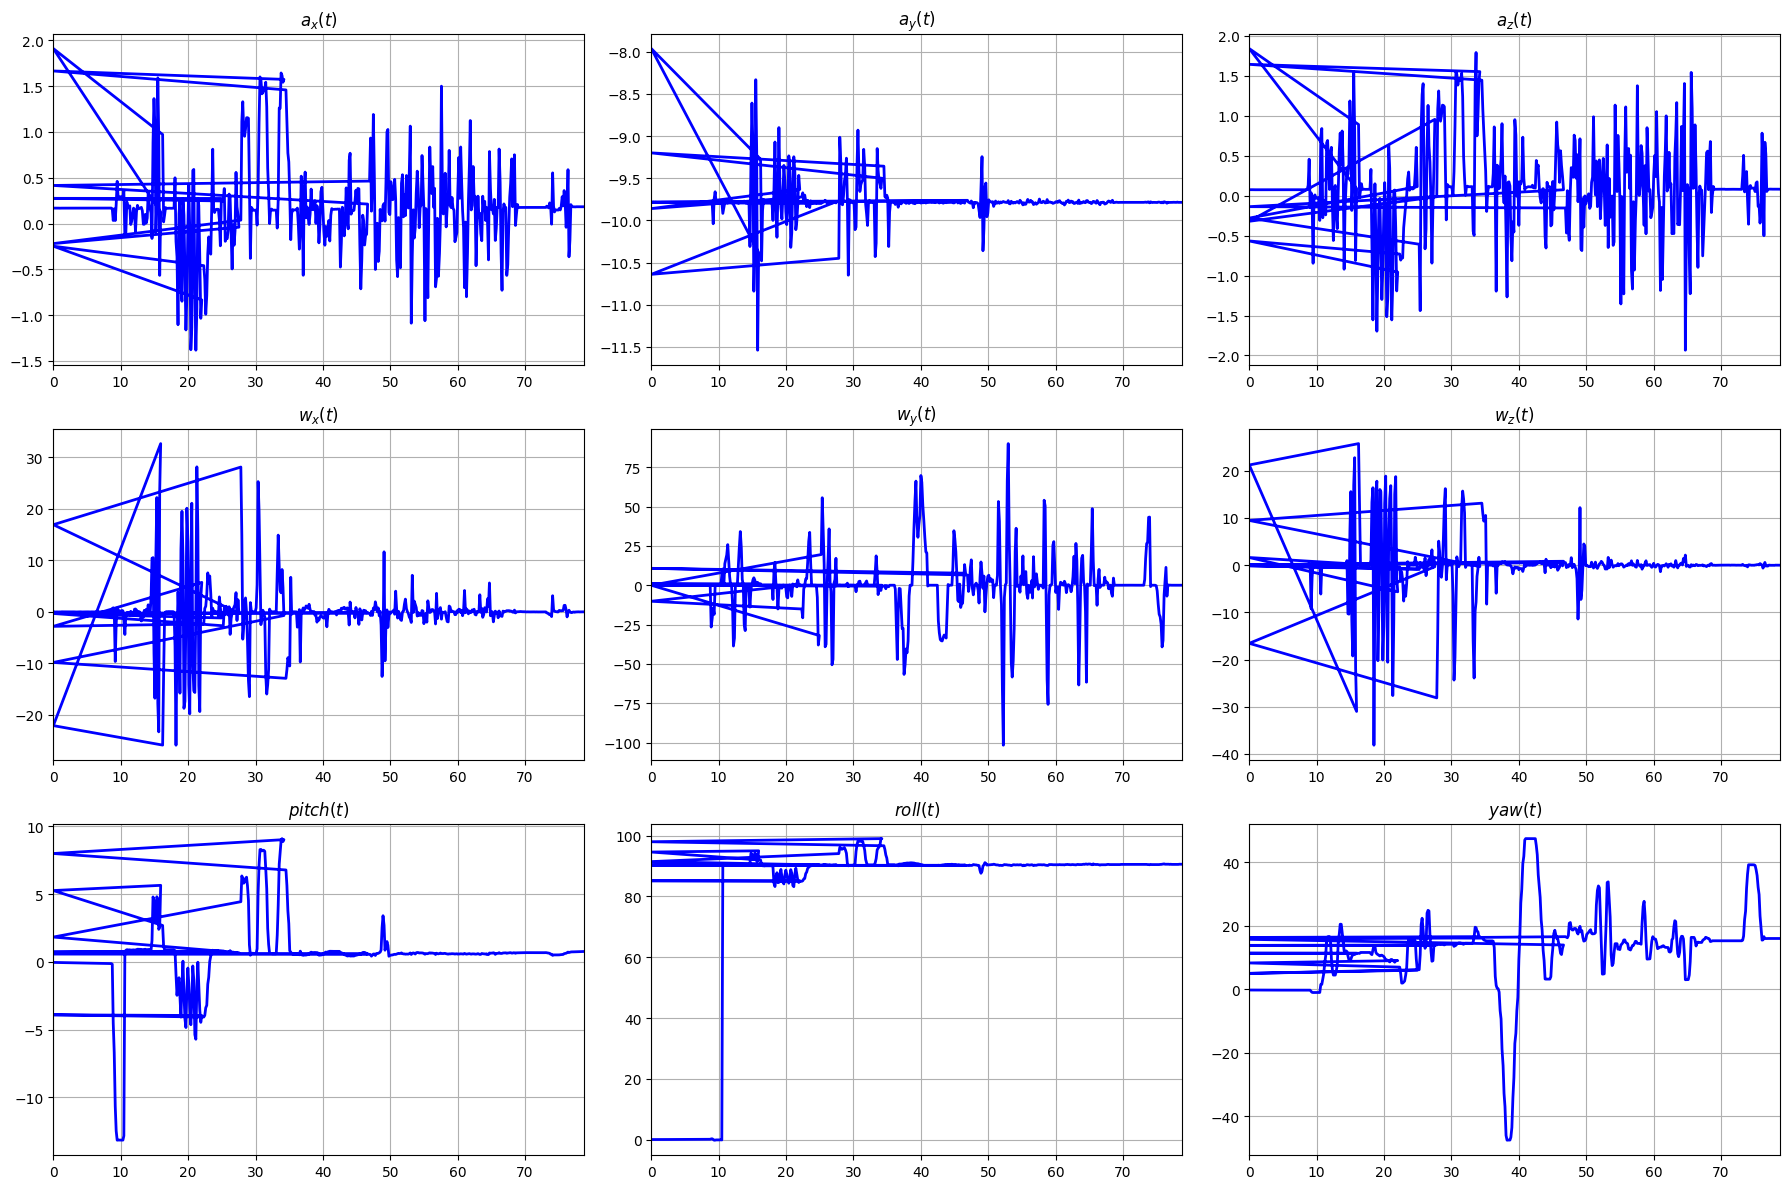

In [7]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

0.14


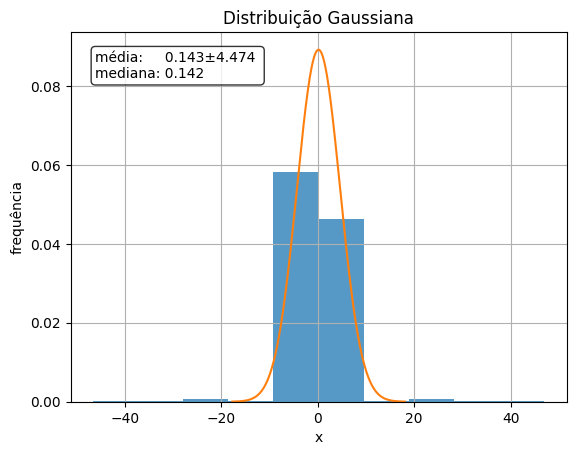

In [ ]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [9]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,az,ay,roll,ax,wz,la_pos_mon_d,wx,q2,sample_time,yaw,q0,q1,wy,pitch,q3
0,0.00,-0.13690,-9.784,90.183557,0.4158,0.066406,-2.879,-0.283958,0.100800,105000000.0,15.767799,0.6997,0.701100,10.725770,0.589001,0.093230
1,0.14,0.07581,-9.787,0.050042,0.1686,-0.021870,0.000,0.028373,-0.000398,405000000.0,-0.207640,1.0000,0.000437,-0.011562,-0.045453,-0.001813
2,0.28,0.07643,-9.784,0.049166,0.1693,0.006205,0.000,-0.027112,-0.000408,505000000.0,-0.207411,1.0000,0.000430,-0.009912,-0.046541,-0.001811
3,0.42,0.07558,-9.787,0.049824,0.1686,-0.012628,0.000,-0.000875,-0.000424,705000000.0,-0.209130,1.0000,0.000436,-0.014863,-0.048295,-0.001827
4,0.56,0.07574,-9.785,0.050695,0.1687,-0.010760,0.000,0.007345,-0.000433,805000000.0,-0.210046,1.0000,0.000444,-0.010966,-0.049383,-0.001834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,78.26,0.08207,-9.786,90.527332,0.1833,-0.006784,-3.404,0.006343,0.103700,505000000.0,16.037089,0.6974,0.702900,0.005272,0.753440,0.093520
560,78.40,0.08176,-9.786,90.584627,0.1831,-0.009018,-3.400,0.017160,0.103700,605000000.0,16.037089,0.6974,0.702900,-0.009947,0.755158,0.093510
561,78.54,0.08186,-9.786,90.584627,0.1831,-0.025411,-3.397,0.020649,0.103700,705000000.0,16.037089,0.6974,0.702900,0.001451,0.758023,0.093490
562,78.68,0.08167,-9.786,90.584627,0.1836,-0.019016,-3.389,0.012645,0.103700,905000000.0,16.037089,0.6974,0.703000,-0.009597,0.761461,0.093470


# FILTRANDO POR VARIAVEL

In [10]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

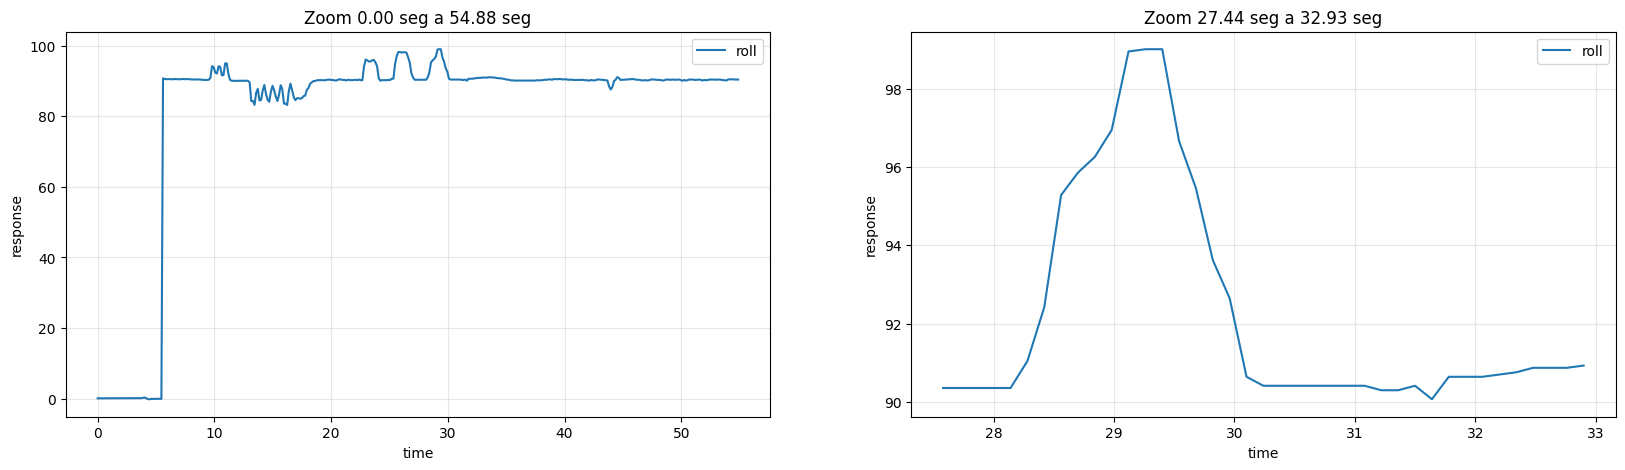

In [11]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [12]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col != 'time'})
df

,time,ref_az,ref_ay,ref_roll,ref_ax,ref_wz,ref_la_pos_mon_d,ref_wx,ref_q2,ref_sample_time,ref_yaw,ref_q0,ref_q1,ref_wy,ref_pitch,ref_q3
36,0.00,0.07501,-9.786,0.084339,0.16820,-0.002935,0.000,0.008720,-0.000824,305000000.0,-0.242590,1.0000,0.000736,-0.011436,-0.094194,-0.002118
37,0.14,0.07507,-9.786,0.085428,0.16850,-0.002102,0.000,0.016507,-0.000831,405000000.0,-0.243679,1.0000,0.000746,-0.006681,-0.094825,-0.002126
38,0.28,0.07526,-9.786,0.086345,0.16830,0.001281,0.000,0.011150,-0.000836,505000000.0,-0.244137,1.0000,0.000753,-0.002006,-0.095512,-0.002131
39,0.42,0.07506,-9.786,0.087663,0.16840,-0.005245,0.000,0.003912,-0.000859,705000000.0,-0.245684,1.0000,0.000764,-0.010972,-0.098148,-0.002144
40,0.56,0.07512,-9.786,0.088522,0.16830,-0.004247,0.000,0.000251,-0.000862,805000000.0,-0.246315,1.0000,0.000771,-0.002652,-0.098549,-0.002149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,54.32,0.05814,-9.787,90.470036,0.16830,0.036010,-3.485,0.080157,0.062930,605000000.0,9.579854,0.7021,0.707200,0.006073,0.597022,0.055100
425,54.46,0.07534,-9.787,90.470036,0.14520,0.124160,-3.488,0.028751,0.063140,705000000.0,9.619961,0.7020,0.707200,0.778650,0.591865,0.055380
426,54.60,-0.27510,-9.798,90.412740,-0.19860,-0.203457,-3.494,-0.539153,0.079180,905000000.0,12.238379,0.7008,0.705400,25.485163,0.573531,0.071570
427,54.74,-0.22100,-9.794,90.412740,-0.15480,-0.463867,-3.497,-0.504375,0.097190,5000000.0,15.160463,0.6989,0.703000,27.702509,0.587855,0.089320


In [13]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)